In [1]:
import os
import numpy as np
import time
import pandas as pd
from scipy import interpolate
import pickle
import sys
from astropy.io import ascii
from astropy.table import Table
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

In [2]:
dp1 = ascii.read("/lustre/lrspec/users/4300/cube/Data/Phot/DP1query4.ecsv")

In [3]:
dp1.info

<Table length=3194>
     name       dtype  unit                                                description                                               
-------------- ------- ---- ---------------------------------------------------------------------------------------------------------
      coord_ra float64  deg                                      Fiducial ICRS Right Ascension of centroid used for database indexing
     coord_dec float64  deg                                          Fiducial ICRS Declination of centroid used for database indexing
   diaObjectId   int64                                             Id of the DiaObject that this DiaForcedSource was associated with.
          band    str1                                            Abstract filter that is not associated with a particular instrument
       psfFlux float32  nJy                              Flux derived from linear least-squares fit of psf model forced on the calexp
    psfFluxErr float32  nJy           Unce

In [4]:
dp1[0]

coord_ra,coord_dec,diaObjectId,band,psfFlux,psfFluxErr,psfDiffFlux,psfDiffFluxErr,expMidptMJD
deg,deg,,,nJy,nJy,nJy,nJy,d
float64,float64,int64,str1,float32,float32,float32,float32,float64
38.59479425116109,7.214630100814734,648374722634973207,g,60940.3,262.304,721.917,282.003,60643.08764135424


In [5]:
len(dp1[dp1["psfFlux"]>0])

3163

In [6]:
len(dp1[dp1["psfFlux"]<0])

31

In [7]:
len(np.unique(dp1["diaObjectId"]))

11

In [40]:
np.unique(dp1["diaObjectId"])

591819074317582360
592913706862510093
592915218690998602
609781520902651937
609782208097419314
609788942606139423
611253629533290657
611255210081255575
611255759837069401
611256447031836769
648374722634973207


In [8]:
dp1 = dp1[dp1["psfFlux"]>0]

In [60]:
sel_objs = np.unique(dp1["diaObjectId"])[3:10]

In [61]:
dp1_sel = dp1[np.isin(dp1["diaObjectId"],sel_objs)]

In [62]:
np.unique(dp1_sel["diaObjectId"])

609781520902651937
609782208097419314
609788942606139423
611253629533290657
611255210081255575
611255759837069401
611256447031836769


In [10]:
list_o_lists = []
for n, obj in enumerate(np.unique(dp1["diaObjectId"])):
    tpbp = []
    
    dp1_obj = dp1[dp1["diaObjectId"] == obj]
    
    for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
        dT1s1 = []
        dT2s2 = []
        for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
            if dp1_obj["band"][i] != dp1_obj["band"][j]:
                dT1 = (mjd1-mjd2)*u.day
                dT1 = int((dT1.to(u.min)/u.min))

                BandPair = dp1_obj["band"][i]+dp1_obj["band"][j]
                
                dT1s1.append((dT1, BandPair))
            
            else:
                dT2 = (mjd1-mjd2)*u.day
                dT2 = int((dT2.to(u.min)/u.min))
                if dT2 != 0:
                    dT2s2.append(dT2)

        tpbp.append((dT1s1, dT2s2))
        
    print(f'{n+1} of {len(np.unique(dp1["diaObjectId"]))}')
                
    list_o_lists.append(tpbp)

1 of 11
2 of 11
3 of 11
4 of 11
5 of 11
6 of 11
7 of 11
8 of 11
9 of 11
10 of 11
11 of 11


In [11]:
for i in range(11):
    print(len(list_o_lists[i]))

143
45
102
382
518
389
607
253
443
254
27


In [22]:
print(list_o_lists[0][0][0][0][0])

5


In [23]:
list_o_lists2 = []
for l in list_o_lists:
    pairs = []
    for i in range(len(l)):
        for dT1bp in l[i][0]:
            for dT2 in l[i][1]:
                pairs.append((dT1bp[0],dT1bp[1],dT2))
    list_o_lists2.append(pairs)
        

In [24]:
for i in range(11):
    print(len(list_o_lists2[i]))

439828
13698
153230
9113792
23038032
9683300
37064512
2503988
14407578
2726772
3506


In [25]:
print(list_o_lists2[0][0])

(5, 'ir', 2)


In [31]:
u1 = (set(list_o_lists2[0]) & set(list_o_lists2[1]) & set(list_o_lists2[2]) & set(list_o_lists2[3]) & set(list_o_lists2[4])& set(list_o_lists2[5])& set(list_o_lists2[6])& set(list_o_lists2[7])& set(list_o_lists2[8])& set(list_o_lists2[9]))

In [30]:
u1

{(-28, 'gr', -8644), (-3, 'gr', -1), (-2, 'gr', 1), (15, 'zr', 2)}

In [33]:
u2 = (set(list_o_lists2[0]) & set(list_o_lists2[2]) & set(list_o_lists2[3]) & set(list_o_lists2[4])& set(list_o_lists2[5])& set(list_o_lists2[6])& set(list_o_lists2[7])& set(list_o_lists2[8])& set(list_o_lists2[9]))

In [58]:
u4 = (set(list_o_lists2[3]) & set(list_o_lists2[4])& set(list_o_lists2[5])& set(list_o_lists2[6])& set(list_o_lists2[7])& set(list_o_lists2[8])& set(list_o_lists2[9])& set(list_o_lists2[10]))

In [59]:
q4 = list(u4)
for i in range(len(q4)):
    # if (-480 < q3[i][0] < 480) and (-1960 < q3[i][2] < 1920):
    if (q4[i][0]== -30) and (q4[i][2] == -1260):
        print(q4[i])


In [15]:
q = list(u)

In [16]:
qdT2s = []
qdT1s = []
for i in range(len(q)):
    qdT2s.append(q[i][0][1])
    qdT1s.append(q[i][0][0])

In [17]:
print(np.unique(qdT2s))

[]


In [389]:
print(np.unique(qdT1s))

[-13171  -8778  -7242  -7201  -5783  -2663  -2629  -2599  -1438  -1388
  -1261    -27    -21    -20     -5     -3     -2     -1      0      1
      2      3      6     11     12     13     14     17     19     20
     24     62   2979   4564   5986   5992  14457  15801  20196  26119
  31329  31355  32790  32803  32804  35882  35883  37315  38772  38782
  38783  38784  38799  38805]


(array([  8.,   4.,   7.,   6.,   7., 119.,   3.,   2.,   4.,   9.]),
 array([-44543., -35931., -27319., -18707., -10095.,  -1483.,   7129.,
         15741.,  24353.,  32965.,  41577.]),
 <BarContainer object of 10 artists>)

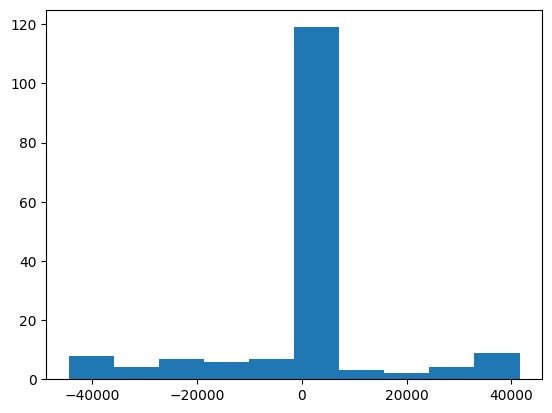

In [386]:
plt.hist(qdT2s)

In [145]:
dp1["diaObjectId"][0]

np.int64(648374722634973207)

In [268]:
dp1_obj = dp1[dp1["diaObjectId"]==dp1["diaObjectId"][2]]

In [269]:
dT1 = dp1_obj["expMidptMJD"][-1] - dp1_obj["expMidptMJD"][0]

In [270]:
dT1 = dT1* u.day

In [271]:
dT1

<Quantity -1.03022312 d>

In [272]:
dT1.to(u.min)

<Quantity -1483.52129184 min>

In [273]:
dT1s = []
for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
    for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
        if dp1_obj["band"][i] != dp1_obj["band"][j]:
            dT1 = (mjd1-mjd2)*u.day
            dT1s.append(int((dT1.to(u.min)/u.min)))


In [274]:
dT1s_per_day = [dT1 for dT1 in dT1s if -1200 < dT1 < 0]
print(len(dT1s_per_day))

47


(array([ 2.,  2.,  2.,  2.,  1.,  3.,  8.,  8.,  8., 11.]),
 array([-47. , -42.6, -38.2, -33.8, -29.4, -25. , -20.6, -16.2, -11.8,
         -7.4,  -3. ]),
 <BarContainer object of 10 artists>)

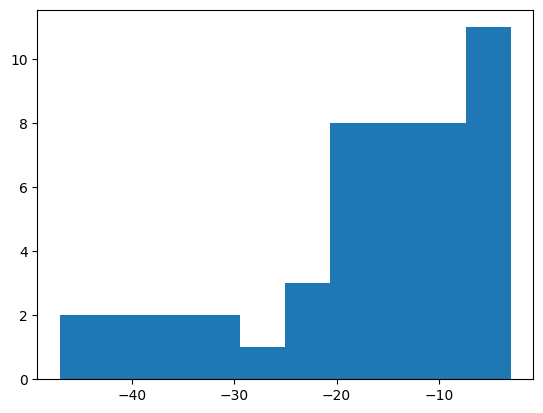

In [275]:
plt.hist(np.array(dT1s_per_day))

In [276]:
np.abs(np.array(dT1s_per_day)).mean()

np.float64(17.06382978723404)

In [277]:
dT1s_per_day2 = [dT1 for dT1 in dT1s_per_day if -121 < dT1 < 121]

(array([ 2.,  2.,  2.,  2.,  1.,  3.,  8.,  8.,  8., 11.]),
 array([-0.78333333, -0.71      , -0.63666667, -0.56333333, -0.49      ,
        -0.41666667, -0.34333333, -0.27      , -0.19666667, -0.12333333,
        -0.05      ]),
 <BarContainer object of 10 artists>)

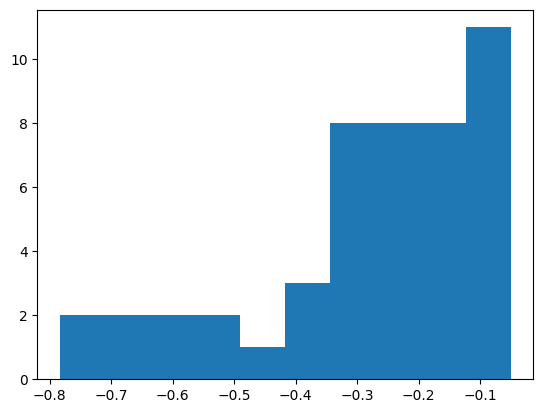

In [278]:
plt.hist(np.array(dT1s_per_day2)/60)

In [279]:
dT1s_per_day

[-10,
 -13,
 -16,
 -7,
 -10,
 -13,
 -3,
 -7,
 -10,
 -7,
 -10,
 -17,
 -20,
 -13,
 -23,
 -3,
 -7,
 -14,
 -17,
 -10,
 -20,
 -22,
 -36,
 -5,
 -12,
 -17,
 -9,
 -14,
 -7,
 -3,
 -47,
 -20,
 -40,
 -7,
 -44,
 -27,
 -20,
 -23,
 -18,
 -32,
 -13,
 -10,
 -40,
 -33,
 -36,
 -10,
 -7]

In [63]:
pref_dT1s = np.arange(-480, 481, 15)
pref_dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 
# pref_dT1s = np.arange(-15,15,1)
# pref_dT2s = [-40, 40, 1490, 1510]

In [281]:

dT1s_filtered = []
dT2s_filtered = []
for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
    for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
        if dp1_obj["band"][i] != dp1_obj["band"][j]:
            dT1 = (mjd1-mjd2)*u.day
            dT1 = int((dT1.to(u.min)/u.min))
            if dT1 in pref_dT1s and dT1 != 0:
                dT1s_filtered.append(dT1)
        else:
            dT2 = (mjd1-mjd2)*u.day
            dT2 = int((dT2.to(u.min)/u.min))
            if dT2 in pref_dT2s and dT2 != 0:
                dT2s_filtered.append(dT2)

(array([2., 0., 0., 0., 0., 0., 0., 0., 0., 2.]),
 array([ 0.66666667,  3.11666667,  5.56666667,  8.01666667, 10.46666667,
        12.91666667, 15.36666667, 17.81666667, 20.26666667, 22.71666667,
        25.16666667]),
 <BarContainer object of 10 artists>)

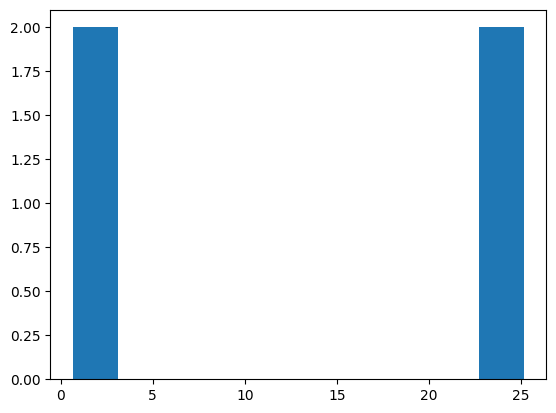

In [282]:
plt.hist(np.array(dT2s_filtered)/60)

In [283]:
dT2s_filtered.count(60)

0

In [284]:
list_o_lists = []
for n, obj in enumerate(np.unique(dp1["diaObjectId"])):
    tpbp = []
    
    dp1_obj = dp1[dp1["diaObjectId"] == obj]
    
    for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
        dT1s2 = []
        dT2s2 = []
        bps = []
        for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
            if dp1_obj["band"][i] != dp1_obj["band"][j]:
                dT1 = (mjd1-mjd2)*u.day
                dT1 = int((dT1.to(u.min)/u.min))

                BandPair = dp1_obj["band"][i]+dp1_obj["band"][j]
                
                dT1s1.append((dT1, BandPair))
            
            else:
                dT2 = (mjd1-mjd2)*u.day
                dT2 = int((dT2.to(u.min)/u.min))
                if dT2 != 0:
                    dT2s2.append(dT2)

        tpbp.append((dT1s2, dT2s2))
        
    print(f'{n+1} of {len(np.unique(dp1["diaObjectId"]))}')
                
    list_o_lists.append(tpbp)




dT1s_filtered = []
dT2s_filtered = []
bandpairs = []
timepairs = []
flux_ratio = []
flux_color = []
for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
    for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
        if dp1_obj["band"][i] != dp1_obj["band"][j]:
            dT1 = (mjd1-mjd2)*u.day
            dT1 = int((dT1.to(u.min)/u.min))

            dflux = dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
            
        else:
            BandPair = [dp1_obj["band"][i]+dp1_obj["band"][j]]

            dT2 = (mjd1-mjd2)*u.day
            dT2 = int((dT2.to(u.min)/u.min))

            color = dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
            
        if dT1 in pref_dT1s and dT1 != 0 and dT2 in pref_dT2s and dT2 != 0:
            dT1s_filtered.append(dT1)
            flux_ratio.append(dflux)
            
            dT2s_filtered.append(dT2)
            flux_color.append(flux_color)

            timepairs.append([dT1,dT2])
            bandpairs.append(BandPair)                


In [285]:
bandpairs

[['ig'], ['ig']]

In [322]:
obj_dfs = []

for n, obj in enumerate(np.unique(dp1["diaObjectId"])):
    dT1s_filtered = []
    dT2s_filtered = []
    bandpairs = []
    timepairs = []
    flux_ratio = []
    flux_color = []
    
    dp1_obj = dp1[dp1["diaObjectId"] == obj]
    
    for i,mjd1 in enumerate(dp1_obj["expMidptMJD"]):
        for j, mjd2 in enumerate(dp1_obj["expMidptMJD"]):
            if dp1_obj["band"][i] != dp1_obj["band"][j]:
                dT1 = (mjd1-mjd2)*u.day
                dT1 = int((dT1.to(u.min)/u.min))
    
                dflux = dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
                
            else:
                BandPair = dp1_obj["band"][i]+dp1_obj["band"][j]
    
                dT2 = (mjd1-mjd2)*u.day
                dT2 = int((dT2.to(u.min)/u.min))
    
                color = dp1["psfFlux"][i] / dp1["psfFlux"][j]
                
            if dT1 in pref_dT1s and dT1 != 0 and dT2 in pref_dT2s and dT2 != 0:
                dT1s_filtered.append(dT1)
                flux_ratio.append(-2.5*np.log10(dflux))
                
                dT2s_filtered.append(dT2)
                flux_color.append(-2.5*np.log10(color))
    
                timepairs.append((dT1,dT2))
                bandpairs.append(BandPair)
                
    obj_pts = pd.DataFrame()
    obj_pts["dT1s"] = dT1s_filtered
    obj_pts["dT2s"] = dT2s_filtered
    obj_pts["dMags"] = flux_ratio
    obj_pts["Colors"] = flux_color
    obj_pts["Timepairs"] = timepairs
    obj_pts["Bandpairs"] = bandpairs

    obj_dfs.append(obj_pts)

    print(f'{n+1} of {len(np.unique(dp1["diaObjectId"]))}')
print("Done!")
        

1 of 11
2 of 11
3 of 11
4 of 11
5 of 11
6 of 11
7 of 11
8 of 11
9 of 11
10 of 11
11 of 11
Done!


In [323]:
print(np.unique(timepairs))
print(np.unique(bandpairs))
bandpair = bandpairs[0]
print(bandpair[0][0])
print(len(obj_dfs))

[ 3  6 40]
['ig']
i
11


In [335]:
for i in range(len(obj_dfs)):
    print(obj_dfs[i]["Timepairs"], obj_dfs[i]["Bandpairs"])

Series([], Name: Timepairs, dtype: float64) Series([], Name: Bandpairs, dtype: float64)
Series([], Name: Timepairs, dtype: float64) Series([], Name: Bandpairs, dtype: float64)
Series([], Name: Timepairs, dtype: float64) Series([], Name: Bandpairs, dtype: float64)
0        (12, 40)
1       (-12, 40)
2       (-14, 40)
3       (-14, 40)
4         (5, 40)
5       (-4, -40)
6       (-5, -40)
7       (-2, -40)
8         (1, 40)
9         (3, 40)
10     (-9, 1490)
11       (-1, 40)
12      (-3, -40)
13     (-12, -40)
14    (-11, 1510)
15      (1, 1510)
Name: Timepairs, dtype: object 0     gr
1     gi
2     gi
3     gi
4     ig
5     ur
6     ur
7     ir
8     rg
9     ri
10    ui
11    gr
12    ig
13    rg
14    ui
15    ur
Name: Bandpairs, dtype: object
0     (-11, -40)
1        (7, 40)
2        (8, 40)
3        (8, 40)
4        (7, 40)
5        (6, 40)
6      (-4, -40)
7     (-13, -40)
8     (-13, -40)
9        (7, 40)
10       (7, 40)
11       (8, 40)
12       (6, 40)
13       (5, 40)
14  

In [324]:
print(obj_dfs[9]["Bandpairs"][obj_dfs[9]["Bandpairs"]=="ig"])

2    (-2, 40)
Name: Timepairs, dtype: object


In [153]:
usable_objs = obj_dfs[

,dT1s,dT2s,dMags,Colors,Timepairs,Bandpairs


In [75]:
print(flux_color[3], flux_ratio[3])
print(-2.5*np.log10(flux_color[3]),-2.5*np.log10(flux_ratio[3]))

0.08239207 0.66984314
2.7102864 0.43506724


In [44]:
def Enquiry(HashTable, InfoDict, Band1, Band2, dT1, dT2, dMag=None, Color=None):
    if abs(dT1) > abs(dT1-dT2):
        dT1, dT2 = dT1-dT2, -dT2    
    Ind1 = InfoDict['BandPairs'].index(Band1+Band2)
    #index for where 1st filter is, 2nd index for 2nd filter
    dT1grid = InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ]
    dT2grid = InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ]
    
    TimePairGrid = np.array([ InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ], InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ] ])
    # above will need some difference to set limit on difference in times
    Ind2 = np.where( (np.array(InfoDict['TimePairs']) == TimePairGrid ).all(axis=1) )[0][0]
    Results = HashTable[Ind1, Ind2]

    if dMag == None:
        pass        
    elif dMag<InfoDict['BinMag'][0] or dMag>=InfoDict['BinMag'][-1]:
        raise ValueError('The value of dMag is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinMag'][0], InfoDict['BinMag'][-1]))        
    else:
        Results = Results[np.where( dMag >= InfoDict['BinMag'] )[0][-1]]       

    if Color == None:
        pass        
    elif Color<InfoDict['BinColor'][0] or Color>=InfoDict['BinColor'][-1]:
        raise ValueError('The value of Color is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinColor'][0], InfoDict['BinColor'][-1]))
        
    else:
        Results = Results[..., np.where( Color >= InfoDict['BinColor'] )[0][-1] ]

    return Results

In [45]:
def loadCubeFile(FilePath):
    
    FileTime = FilePath[FilePath.find('Cube_')+4: FilePath.rfind('__')]
    
    with open(FilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        print(InfoDict)
        HashTable = pickle.load(f)
    
    dT1Range = [InfoDict['dT1s'][0], InfoDict['dT1s'][-1]]
    dT2Range = [InfoDict['dT2s'][0], InfoDict['dT2s'][-1]]    
    dT1step = ( InfoDict['dT1s'][1:] - InfoDict['dT1s'][:-1] ).min()
    dT2step = ( InfoDict['dT2s'][1:] - InfoDict['dT2s'][:-1] ).min()
        
    StartObjNo = 'n/a'
    
    if 'StartObjNo' in InfoDict:
        StartObjNo = InfoDict['StartObjNo']
        
   # print('{:<35}ObjectNo: {:>5}, start at {:>3}. dT1 range = {}, step = {:>3}. dT2 range = {}, step = {:>3}. BandpairNo: {}.'.format(
   #     InfoDict['EventNames']+FileTime, InfoDict['ObjectNo'], StartObjNo, dT1Range, dT1step, dT2Range, dT2step, len(InfoDict['BandPairs'])))

    # InfoDict['OutliersRatio'] = InfoDict['Outliers'] / HashTable.sum()

    if 'Outliers' in InfoDict:
        print('\t{} outliers found, the ratio to the max value is {:.12f}.'.format(InfoDict['Outliers'], InfoDict['OutliersRatio']) )
        print('\tdMag range is {}, \n\tColor range is {}.'.format( InfoDict['dMagRange'], InfoDict['ColorRange'] ) )

    if 'Overflow' in InfoDict:
        print('\tData in the HashTable overflowed, the minimun value is {}.'.format(InfoDict['Overflow']))
        
    return InfoDict, HashTable;

In [53]:
FilePath2 = '/lustre/lrspec/users/4300/cube/Data/Datacube/SNIa-SALT2/ProbCube_0605_1400__SNIa-SALT2.pkl'
InfoDict, HashTable = loadCubeFile(FilePath2) 

{'EventName': 'SNIa-SALT2', 'PointsPerDay': 1, 'ObjectNo': 200, 'BandPairs': ['ug', 'ur', 'ui', 'uz', 'gu', 'gr', 'gi', 'gz', 'gy', 'ru', 'rg', 'ri', 'rz', 'ry', 'iu', 'ig', 'ir', 'iz', 'iy', 'zu', 'zg', 'zr', 'zi', 'zy', 'yg', 'yr', 'yi', 'yz'], 'dT1s': array([-480, -465, -450, -435, -420, -405, -390, -375, -360, -345, -330,
       -315, -300, -285, -270, -255, -240, -225, -210, -195, -180, -165,
       -150, -135, -120, -105,  -90,  -75,  -60,  -45,  -30,  -15,    0,
         15,   30,   45,   60,   75,   90,  105,  120,  135,  150,  165,
        180,  195,  210,  225,  240,  255,  270,  285,  300,  315,  330,
        345,  360,  375,  390,  405,  420,  435,  450,  465,  480]), 'dT2s': array([-1920, -1890, -1860, -1830, -1800, -1770, -1740, -1710, -1680,
       -1650, -1620, -1590, -1560, -1530, -1500, -1470, -1440,  -480,
        -450,  -420,  -390,  -360,  -330,  -300,  -270,  -240,  -210,
        -180,  -150,  -120,   -90,   -60,   -30,     0,    30,    60,
          90,   120,   

In [111]:
def PlotSlice(HashTable1, InfoDict1, Band1, Band2, dT1, dT2, ax = None):
    # cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)

    

    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000

    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                        norm=LogNorm(1, vmax=Map1.max()+1), cmap="gist_grey")

        # ax.scatter(Data[0], Data[1], c='mediumpurple', s=1, alpha=0.1, )


    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 


In [325]:
for bandpair in np.unique(obj_pts[0]["Bandpairs"]):
    print(bandpair, obj_pts["Timepairs"][obj_pts["Bandpairs"]==bandpair])

KeyError: 0

In [125]:
obj_dfs[8]["Bandpairs"]

0    ur
1    gr
2    zi
3    iu
4    iu
5    ru
6    ir
7    gr
8    ig
Name: Bandpairs, dtype: object

In [124]:
obj_dfs[8]["Timepairs"]

0     (-15, 1500)
1      (165, 180)
2      (30, 1590)
3    (-45, -1500)
4     (75, -1440)
5     (45, -1470)
6       (30, -30)
7        (45, 60)
8     (-30, 1710)
Name: Timepairs, dtype: object

In [ ]:
obj_pts["dMags"][obj_pts["Timepairs"] == obj_pts["Timepairs"][0]]

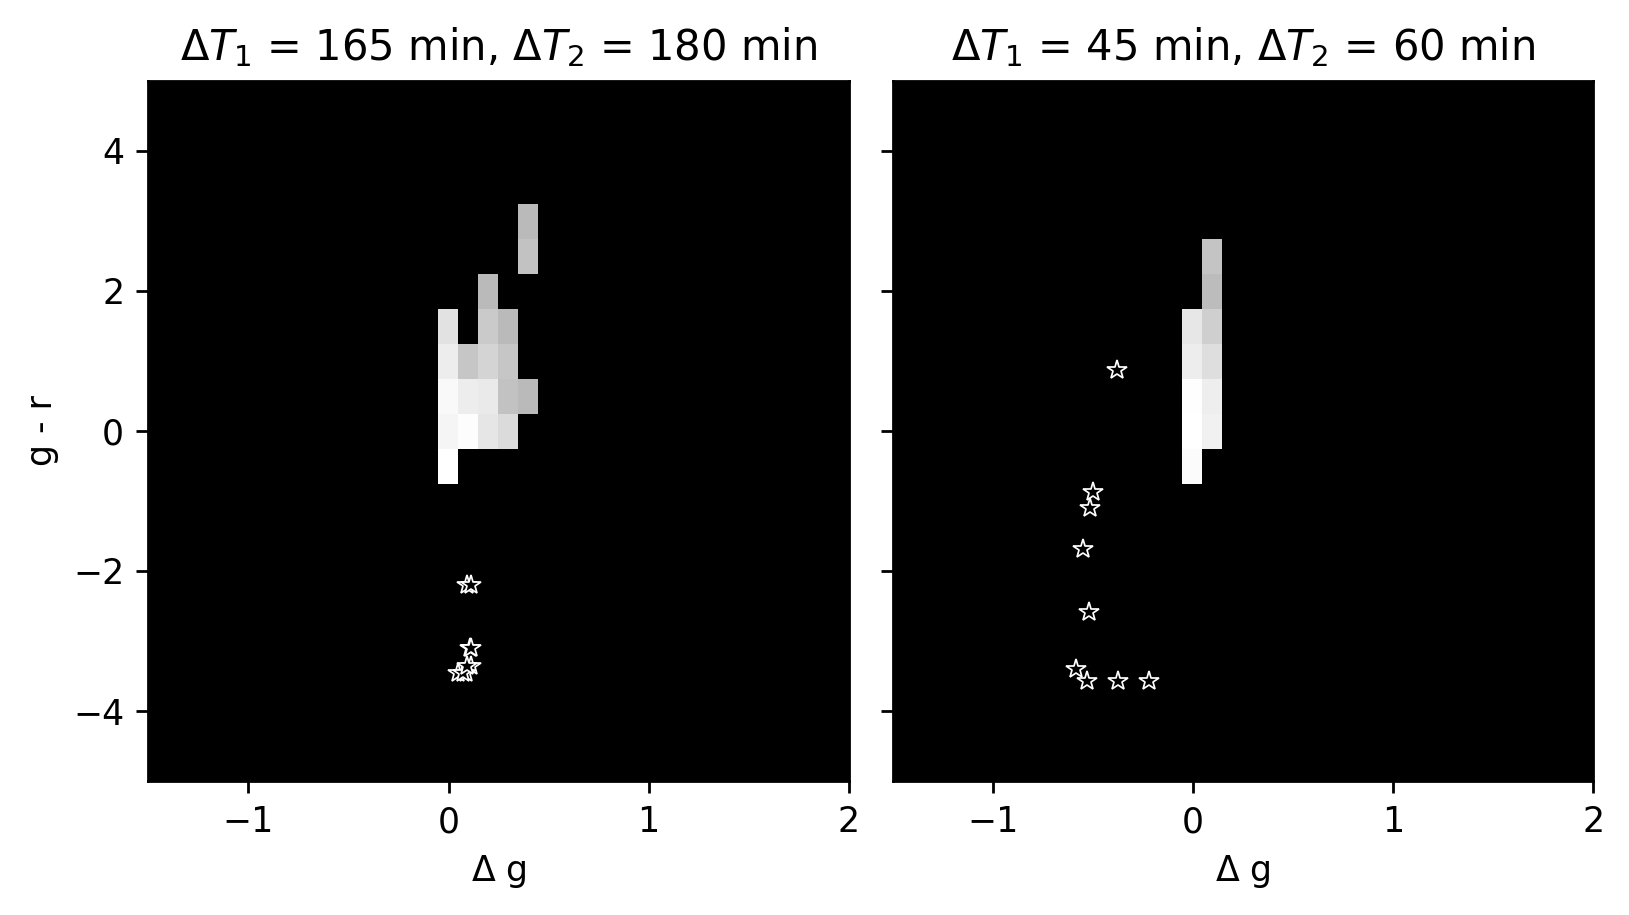

In [114]:
# bandpairs = [["u","g"], ["i", "r"], ["g","i"]]
# timepairs = [[60,60], [60, 360]]
bandpairs = ["gr"]
timepairs = [(165,180),(45,60)]

fig, axs = plt.subplots(len(bandpairs), len(timepairs), squeeze = False, sharey = True, 
                        #figsize = (6, 8), 
                        dpi = 250, layout = "constrained")
for i in range(len(bandpairs)):
    for j in range(len(timepairs)):
        
        
        PlotSlice(HashTable, InfoDict, bandpairs[i][0],bandpairs[i][1],
                            timepairs[j][0],timepairs[j][1], ax = axs[i][j])
        
        # RandomPoint = [np.random.uniform(-1.5,2),np.random.uniform(-5,8)]
        for obj_pts in obj_dfs:
            axs[i][j].plot(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]],
                           obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]], 
                           "*", mec = "white", mew = 0.5, color = "black")
        
        axs[i][j].set_box_aspect(1)
        axs[i][j].set_xlabel(f"$\\Delta$ {bandpairs[i][0]}")

        if i == 0:
            axs[i][j].set_title(f"$\\Delta T_1$ = {timepairs[j][0]} min, $\\Delta T_2$ = {timepairs[j][1]} min")
        if j == 0:
            axs[i][j].set_ylabel(f"{bandpairs[i][0]} - {bandpairs[i][1]}")
#plt.savefig("/lustre/lrspec/users/4300/cube/Figures/Color_Switch_Neg_CAAT_w_SS_6060_60360_ug_ir_gi")

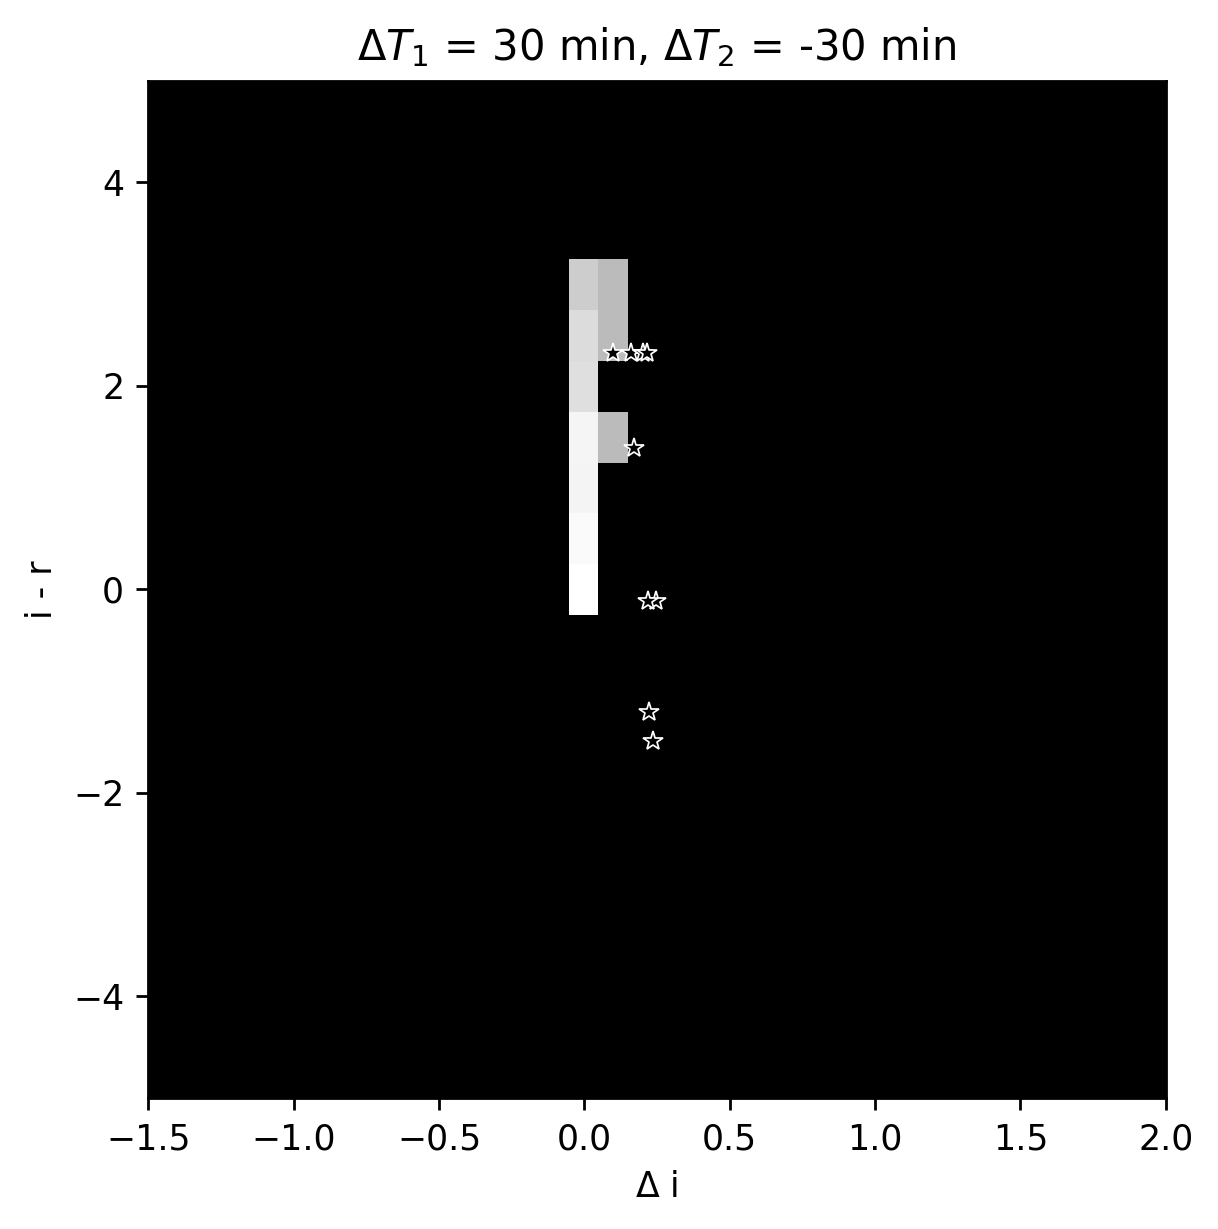

In [126]:
# bandpairs = [["u","g"], ["i", "r"], ["g","i"]]
# timepairs = [[60,60], [60, 360]]
bandpairs = ["ir"]
timepairs = [(30,-30)]

fig, axs = plt.subplots(len(bandpairs), len(timepairs), squeeze = False, sharey = True, 
                        #figsize = (6, 8), 
                        dpi = 250, layout = "constrained")
for i in range(len(bandpairs)):
    for j in range(len(timepairs)):
        
        
        PlotSlice(HashTable, InfoDict, bandpairs[i][0],bandpairs[i][1],
                            timepairs[j][0],timepairs[j][1], ax = axs[i][j])
        
        # RandomPoint = [np.random.uniform(-1.5,2),np.random.uniform(-5,8)]
        for obj_pts in obj_dfs:
            axs[i][j].plot(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]],
                           obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]], 
                           "*", mec = "white", mew = 0.5, color = "black")
        
        axs[i][j].set_box_aspect(1)
        axs[i][j].set_xlabel(f"$\\Delta$ {bandpairs[i][0]}")

        if i == 0:
            axs[i][j].set_title(f"$\\Delta T_1$ = {timepairs[j][0]} min, $\\Delta T_2$ = {timepairs[j][1]} min")
        if j == 0:
            axs[i][j].set_ylabel(f"{bandpairs[i][0]} - {bandpairs[i][1]}")
#plt.savefig("/lustre/lrspec/users/4300/cube/Figures/Color_Switch_Neg_CAAT_w_SS_6060_60360_ug_ir_gi")

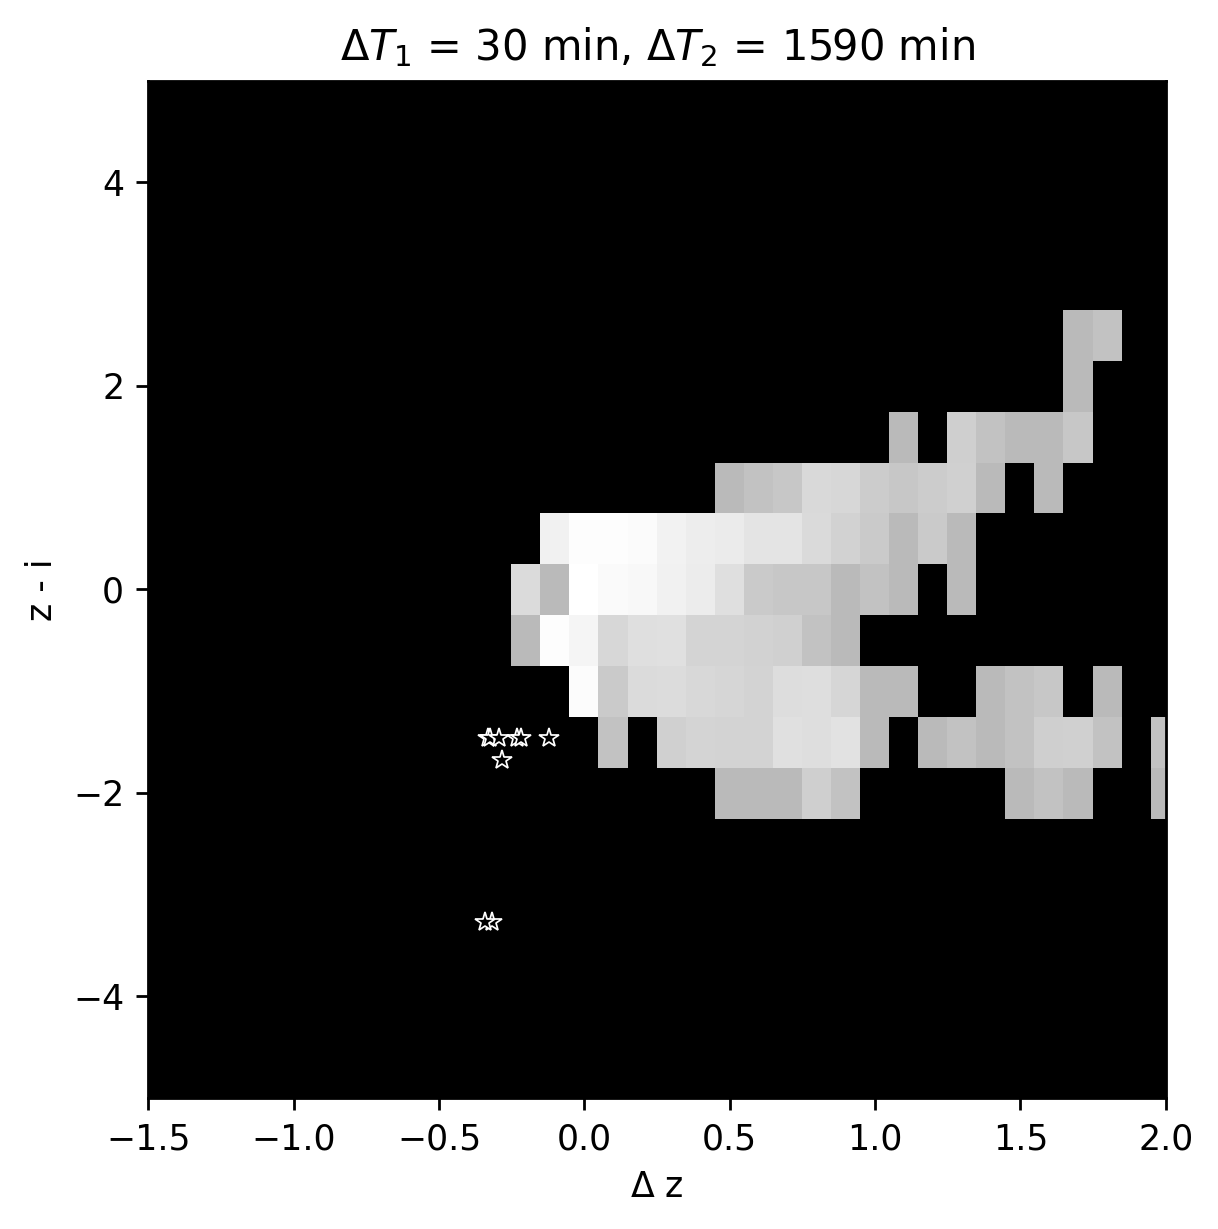

In [127]:
# bandpairs = [["u","g"], ["i", "r"], ["g","i"]]
# timepairs = [[60,60], [60, 360]]
bandpairs = ["zi"]
timepairs = [(30, 1590)]

fig, axs = plt.subplots(len(bandpairs), len(timepairs), squeeze = False, sharey = True, 
                        #figsize = (6, 8), 
                        dpi = 250, layout = "constrained")
for i in range(len(bandpairs)):
    for j in range(len(timepairs)):
        
        
        PlotSlice(HashTable, InfoDict, bandpairs[i][0],bandpairs[i][1],
                            timepairs[j][0],timepairs[j][1], ax = axs[i][j])
        
        # RandomPoint = [np.random.uniform(-1.5,2),np.random.uniform(-5,8)]
        for obj_pts in obj_dfs:
            axs[i][j].plot(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]],
                           obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[i]][obj_pts["Timepairs"]==timepairs[j]], 
                           "*", mec = "white", mew = 0.5, color = "black")
        
        axs[i][j].set_box_aspect(1)
        axs[i][j].set_xlabel(f"$\\Delta$ {bandpairs[i][0]}")

        if i == 0:
            axs[i][j].set_title(f"$\\Delta T_1$ = {timepairs[j][0]} min, $\\Delta T_2$ = {timepairs[j][1]} min")
        if j == 0:
            axs[i][j].set_ylabel(f"{bandpairs[i][0]} - {bandpairs[i][1]}")
#plt.savefig("/lustre/lrspec/users/4300/cube/Figures/Color_Switch_Neg_CAAT_w_SS_6060_60360_ug_ir_gi")

In [128]:
EventNames = ['AGN', 'CART', 'EB', 'ILOT', 'KN_B19', 'KN_K17', 'MIRA', 'Mdwarf',
              'PISN', 'RRL', 'SLSN-I', 'SNII-NMF', 'SNII-Templates', 'SNIIn',
              'SNIa-91bg', 'SNIa-SALT2', 'SNIax', 'SNIbc-MOSFIT',
              'SNIbc-Templates', 'TDE', 'V19_CC+HostXT', 'uLens-Binary',
              'uLens-Single-GenLens', 'uLens-Single_PyLIMA']


In [129]:
PathCubeFolder = '/lustre/lrspec/users/4300/cube/Data/Datacube/All_Events'
CubeFileNames = os.listdir(PathCubeFolder)
CubeFileNames = [ ii for ii in CubeFileNames if '.pkl' in ii ]

In [ ]:
print(bandpairs[0]

||||||||||||||||||||||||

(-5.0, 8.0)

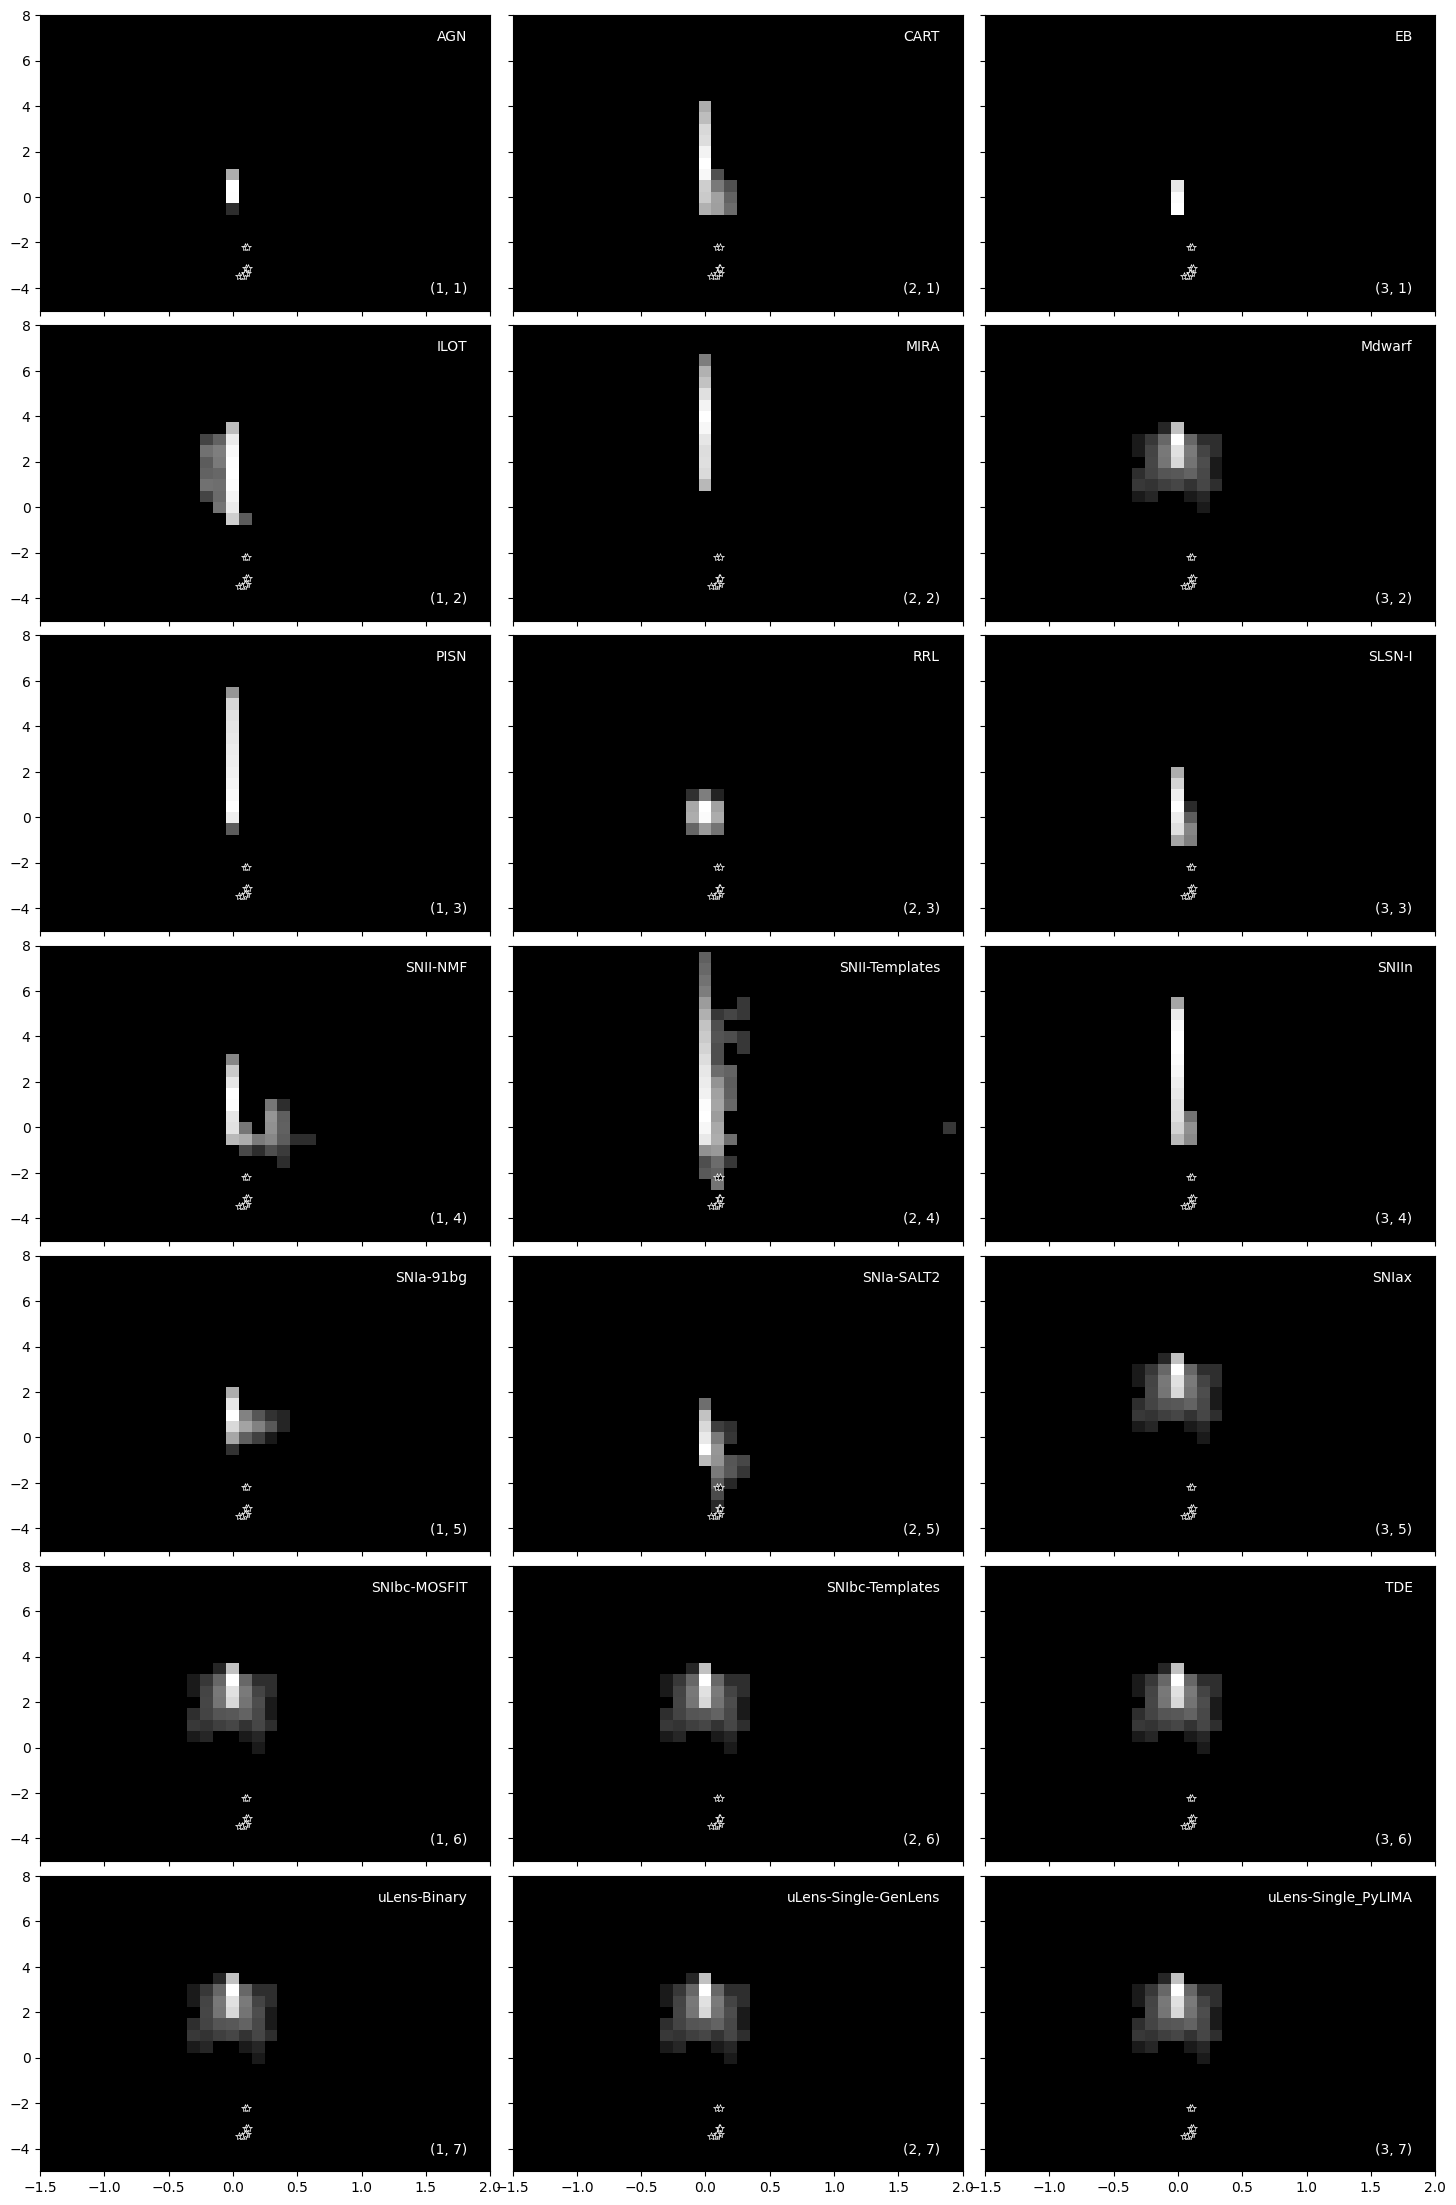

In [137]:
bandpairs = ["gr"]
timepairs = [(165,180),(45,60)]
Band1 = 'g'
Band2 = 'i'
dT1 = 165
dT2 = 180


Space = 0.05
ColNo = 3
RowNo = 7

fig, axs = plt.subplots(RowNo, ColNo, figsize = (18, 4*RowNo), sharex=True, sharey=True)
fig.subplots_adjust(hspace=Space, wspace=Space)
axsflat = axs.flatten()

ii=0

for EventName in EventNames:
    
    print('|', end='')

    if EventName == 'V19_CC+HostXT'or 'KN' in EventName:
        continue
    for CubeFileName in CubeFileNames:
        if EventName in CubeFileName:
            break
            
    CubeFilePath = os.path.join(PathCubeFolder, CubeFileName)

    with open(CubeFilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        Cube = pickle.load(f)
        
    CubeNorm = Cube / Cube.max(-1, keepdims=True).max(-2, keepdims=True)
    np.nan_to_num(CubeNorm, copy=False);
    
    Map = Enquiry(CubeNorm, InfoDict, Band1, Band2, dT1, dT2)    
    
    Map = Map*100000
    
    axsflat[ii].pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map)+1,
                      norm=LogNorm(1, vmax=Map.max()+1), cmap='gist_gray')

    for obj_pts in obj_dfs:
        axsflat[ii].plot(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[0]][obj_pts["Timepairs"]==timepairs[0]],
                       obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[0]][obj_pts["Timepairs"]==timepairs[0]], 
                       "*", mec = "white", mew = 0.5, color = "black")


    
    axsflat[ii].text(0.95, 0.95, EventName, c='w', ha='right', va='top', transform=axsflat[ii].transAxes)    
    axsflat[ii].text(0.95, 0.05, '({}, {})'.format(ii%3+1, ii//3+1), 
                     c='w', ha='right', va='bottom', transform=axsflat[ii].transAxes)  

    ii += 1
        
axs[0,0].set_xlim([-1.5, 2])
axs[0,0].set_ylim([-5, 8])